# modle loading

In [ ]:
import os
from dotenv import load_dotenv
# 1. Load variables from the .env file
load_dotenv()
OLLAMA_API_KEY = os.environ.get("OLLAMA_API_KEY")
GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY")
TAVILY_API_KEY = os.environ.get("TAVILY_API_KEY")



from langchain.chat_models import init_chat_model
import os



llm = init_chat_model(
    "google_genai:gemini-2.5-flash"
)

response = llm.invoke(
    "What is the color of the sky answer in one word?"
)

print(response.content)


llm = init_chat_model(
    "ollama:nemotron-3-super:cloud",
    base_url="https://ollama.com",
)

response = llm.invoke(
    "What is the color of the sky answer in one word?"
)

print(response.content)

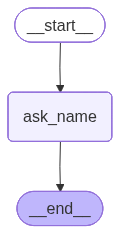

{'__interrupt__': [Interrupt(value='What is your name?', id='6ed8379d15feff5b8564f6acce4ad1da')]}


In [9]:
from typing import TypedDict

class State(TypedDict):
    name: str


from langgraph.types import interrupt

def ask_name(state):
    
    name = interrupt(
        "What is your name?"
    )

    return {
        "name": name
    }


from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
checkpointer = InMemorySaver()


builder = StateGraph(State)

builder.add_node("ask_name", ask_name)

builder.add_edge(START, "ask_name")
builder.add_edge("ask_name", END)

graph = builder.compile(checkpointer=checkpointer)

from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))



config = {
    "configurable": {
        "thread_id": "1"
    }
}

result = graph.invoke(
    {},
    config=config
)

print(result)

In [10]:
result

{'__interrupt__': [Interrupt(value='What is your name?', id='6ed8379d15feff5b8564f6acce4ad1da')]}

In [11]:
from langgraph.types import Command

graph.invoke(
    Command(resume="Kunnu"),
    config=config
)

{'name': 'Kunnu'}